MODUL IV

MORFOLOGI

IMPORT LIBRARY

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

Library yang digunakan dalam praktikum ini adalah OpenCV (cv2) untuk membaca dan mengonversi format citra, Matplotlib untuk menampilkan hasil citra secara visual, serta NumPy untuk operasi array dan komputasi numerik yang digunakan di seluruh proses pengolahan citra.

MEMBACA GAMBAR DAN MELAKUKAN GRAYSCALE

Dilakukan pembacaan gambar yang akan digunakan sebagai bahan untuk melakukan proses perbaikan citra dan pendeteksian tepi yang kemudian disimpan pada variabel tertentu dengan menggunakan fungsi "imread" dari library OpenCV. Gambar akan diubah menjadi grayscale

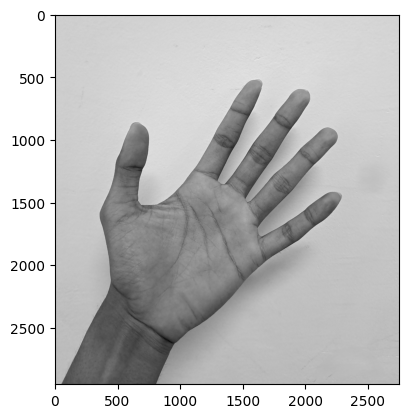

In [2]:
tangan = cv.imread("tangan.jpg")
tangan_gray = cv.cvtColor(tangan, cv.COLOR_BGR2GRAY)
plt.imshow(tangan_gray, cmap='gray')

In [3]:
def filter_sliding(img, size, mode):
    height, width = img.shape
    pad            = size // 2                          # ukuran padding
    padded         = np.pad(img, pad, mode='edge')      # padding tepi
    canvas         = np.zeros_like(img, dtype=np.uint8) # kanvas hasil

    if mode == 'mean':
        #jumlah semua piksel dibagi banyaknya piksel
        total_elemen = size * size
        for i in range(height):
            for j in range(width):
                region = padded[i : i+size, j : j+size]
                jumlah = 0.0
                for r in range(size):
                    for c in range(size):
                        jumlah += float(region[r, c])
                canvas[i, j] = int(jumlah / total_elemen)

    elif mode == 'median':
        #urutkan (bubble sort), ambil nilai tengah
        for i in range(height):
            for j in range(width):
                region = padded[i : i+size, j : j+size]
                vals   = []
                for r in range(size):
                    for c in range(size):
                        vals.append(int(region[r, c]))
                # bubble sort ascending
                n = len(vals)
                for a in range(n - 1):
                    for b in range(n - 1 - a):
                        if vals[b] > vals[b+1]:
                            vals[b], vals[b+1] = vals[b+1], vals[b]
                canvas[i, j] = vals[n // 2]

    elif mode == 'modus':
        #hitung frekuensi, ambil nilai terbanyak
        for i in range(height):
            for j in range(width):
                region = padded[i : i+size, j : j+size]
                vals   = []
                for r in range(size):
                    for c in range(size):
                        vals.append(int(region[r, c]))
                count = {}
                for val in vals:
                    if val in count:
                        count[val] += 1
                    else:
                        count[val] = 1
                max_count = 0
                mode_val  = vals[0]
                for val, freq in count.items():
                    if freq > max_count:
                        max_count = freq
                        mode_val  = val
                canvas[i, j] = mode_val

    return canvas

tangan_gray_filter = filter_sliding(tangan_gray, 5, 'median')

Fungsi filter_sliding merupakan fungsi yang digunakan untuk melakukan filtering spasial pada gambar grayscale menggunakan metode sliding window dengan tiga pilihan mode yaitu mean, median, dan modus. Fungsi ini bekerja dengan cara menambahkan padding di sekeliling gambar menggunakan nilai piksel tepi (mode='edge') agar dimensi output tetap sama dengan input, kemudian menggeser window berukuran size×size di atas setiap piksel gambar untuk mengambil area region yang akan diproses sesuai mode yang dipilih.
Pada mode mean, fungsi menjumlahkan seluruh nilai piksel dalam region kemudian membaginya dengan total jumlah elemen (size×size) untuk menghasilkan nilai rata-rata yang disimpan sebagai piksel output. Pada mode median, fungsi mengumpulkan semua nilai piksel dalam region ke dalam sebuah list menggunakan append, kemudian mengurutkannya secara ascending menggunakan algoritma bubble sort manual, lalu mengambil nilai tengah pada indeks n//2 sebagai piksel output. Pada mode modus, fungsi mengumpulkan semua nilai piksel dalam region ke dalam list, kemudian menghitung frekuensi kemunculan setiap nilai menggunakan count secara manual, lalu mencari nilai dengan frekuensi tertinggi sebagai piksel output. Ketiga mode tersebut menghasilkan efek yang berbeda, mean menghaluskan gambar secara merata, median efektif menghilangkan noise ekstrem tanpa merusak tepi, dan modus mempertahankan nilai yang paling dominan dalam setiap area window.

In [4]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image
tangan_resize = resize(tangan_gray_filter, 256, 256)
resize_filter = filter_sliding(tangan_resize, 3, 'median')

Fungsi resize mengubah ukuran citra menjadi dimensi baru menggunakan metode nearest-neighbor interpolation secara manual. Untuk setiap piksel pada citra output, fungsi memetakan koordinatnya ke koordinat piksel terdekat pada citra asli dengan rumus proporsi, lalu menyalin nilai piksel tersebut langsung tanpa interpolasi. Pada kode ini, citra hasil filter diterapkan resize menjadi 256×256 piksel, kemudian dilakukan filter median 3×3 sekali lagi pada hasil resize untuk mengurangi artefak kotak yang muncul akibat proses downsampling nearest-neighbor.

MATRIKS KERNEL

In [5]:
sobelX = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [ 1,  0],
    [ 0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0,  1],
    [-1,  0]
], dtype=np.float32)

Kode di atas merupakan kernel yang digunakan dalam penghitungan menggunakan operator Sobel, Prewitt, dan Roberts, untuk menghasilkan deteksi tepi pada gambar.

In [6]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

kernel_diamond = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
])

kernel_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

kernel_x = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
], dtype=np.uint8)

Kernels di atas dikelompokkan menjadi dua kategori. Pertama, kernelSmoothing dan kernelSharpening digunakan dalam tahap perbaikan citra sebelum deteksi tepi, kernelSmoothing meratakan nilai piksel untuk meredam noise, sedangkan kernelSharpening memperkuat perbedaan intensitas antar piksel untuk mempertegas detail. Kedua, kernel morfologi khusus yaitu kernel_diamond (5×5 berbentuk belah ketupat), kernel_cross (3×3 berbentuk plus), dan kernel_x (5×5 berbentuk silang diagonal) digunakan pada tahap eksplorasi morfologi untuk memberikan arah ekspansi atau erosi yang berbeda sesuai bentuknya masing-masing.

In [7]:
def convolution(image, kernel):
    size     = kernel.shape[0]
    pad_size = size // 2
    padded   = np.pad(image, pad_size, mode='constant')
    canvas   = np.zeros_like(image, dtype=np.float32)

    height, width = image.shape
    for i in range(height):
        for j in range(width):
            region = padded[i : i+size, j : j+size]
            total  = 0.0
            for r in range(size):
                for c in range(size):
                    total += float(region[r, c]) * float(kernel[r, c])
            canvas[i, j] = total

    return canvas

Fungsi convolution merupakan fungsi utama yang digunakan untuk melakukan operasi konvolusi antara sebuah gambar grayscale dengan kernel tertentu secara manual piksel per piksel. Fungsi ini bekerja dengan cara menambahkan padding bernilai 0 di sekeliling gambar agar piksel di tepi tetap dapat diproses, kemudian menggeser kernel di atas setiap piksel gambar, mengalikan nilai piksel dengan bobot kernel yang bersesuaian, lalu menjumlahkan seluruh hasilnya menjadi satu nilai output yang disimpan ke kanvas hasil.

In [8]:
def edge(image, kernelx, kernely):
    gx = convolution(image.astype(np.float32), kernelx)
    gy = convolution(image.astype(np.float32), kernely)
    canvas = np.zeros_like(image, dtype=np.float32)

    abs_gx = np.abs(gx)
    abs_gy = np.abs(gy)

    h, w = image.shape
    for i in range(h):
        for j in range(w):
            canvas[i, j] = abs_gx[i, j] + abs_gy[i, j]

    maks = np.max(canvas)
    if maks == 0:
        return np.zeros_like(image, dtype=np.uint8)

    result = np.zeros_like(canvas, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            norm_val = canvas[i, j] * 255.0 / maks
            if   norm_val > 255: result[i, j] = 255
            elif norm_val < 0:   result[i, j] = 0
            else:                result[i, j] = int(norm_val)

    return result

Fungsi edge merupakan sebuah fungsi yang digunakan untuk melakukan proses deteksi tepi pada citra grayscale dengan memanfaatkan operasi konvolusi menggunakan kernel arah horizontal (kernelx) dan vertikal (kernely). Fungsi ini bekerja dengan cara menghitung gradien citra pada dua arah, yaitu gx untuk gradien horizontal dan gy untuk gradien vertikal, kemudian mengambil nilai absolut dari masing-masing gradien agar hanya besarnya perubahan intensitas yang diperhitungkan tanpa melihat arah. Nilai gradien tersebut digabungkan ke dalam sebuah canvas sehingga menghasilkan representasi kekuatan tepi pada setiap piksel.  

In [9]:
def threshold(image, batas):
    baris, kolom = image.shape
    canvas = np.zeros_like(image, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if image[i, j] > batas:
                canvas[i, j] = 255
            elif image[i, j] <= batas:
                canvas[i, j] = 0
    return canvas

Fungsi threshold melakukan binarisasi citra dengan membandingkan setiap nilai piksel terhadap nilai ambang (batas). Piksel yang nilainya lebih besar dari batas akan diset menjadi 255 (putih), sedangkan piksel yang nilainya lebih kecil atau sama dengan batas akan diset menjadi 0 (hitam). Hasil akhirnya adalah citra biner yang hanya mengandung dua nilai, digunakan sebagai input utama untuk seluruh operasi morfologi berikutnya.

Potongan kode di bawah merupakan persiapan sebelum morfologi dilakukan. Citra hasil resize yang telah difilter dihaluskan menggunakan kernelSmoothing lalu dipertajam dengan kernelSharpening untuk mempersiapkan tepi yang lebih tegas. Deteksi tepi dilakukan menggunakan dua operator sekaligus, yaitu Sobel dan Prewitt, yang hasilnya dijumlahkan menjadi variabel combo agar tepi yang terdeteksi lebih kuat dan lengkap. Nilai combo kemudian dibinarisasi menggunakan threshold dengan batas 30 sehingga menghasilkan citra biner thres_tangan yang menjadi input semua operasi morfologi. Keempat tahapan, citra asli, hasil resize, deteksi tepi, dan threshold.

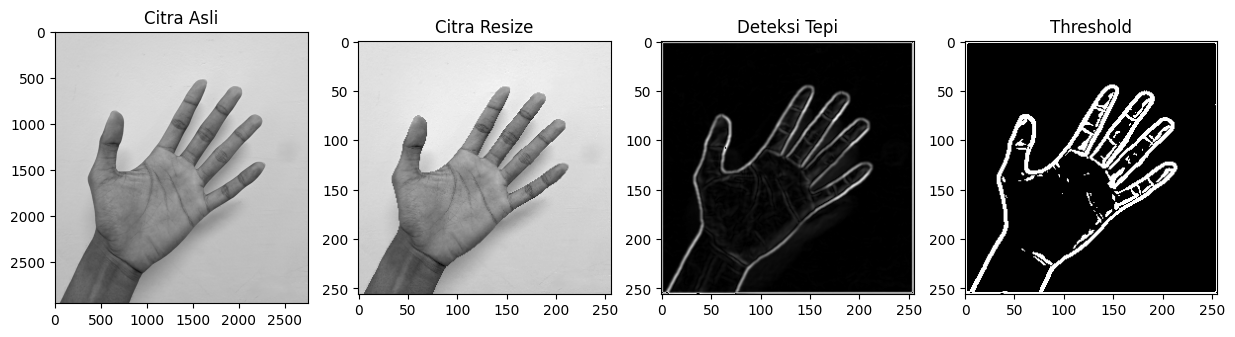

In [10]:
resize_smooth = convolution(resize_filter, kernelSmoothing)
resize_sharp = convolution(resize_smooth, kernelSharpening)
edge_sobel = edge(resize_sharp, sobelX, sobelY)
edge_prewitt = edge(resize_sharp, prewittX, prewittY)
combo = edge_sobel+edge_prewitt
thres_tangan = threshold(combo, 30)

plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.title("Citra Asli")
plt.imshow(tangan_gray, cmap='gray')
plt.subplot(1,4,2)
plt.title("Citra Resize")
plt.imshow(tangan_resize, cmap='gray')
plt.subplot(1,4,3)
plt.title("Deteksi Tepi")
plt.imshow(combo, cmap='gray')
plt.subplot(1,4,4)
plt.title("Threshold")
plt.imshow(thres_tangan, cmap='gray')

FUNGSI MORFOLOGI

In [11]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil

Fungsi dilasi bekerja dengan memeriksa setiap piksel citra, jika piksel bernilai 255 (putih), maka semua piksel tetangga yang bersesuaian dengan elemen kernel bernilai 1 akan diset menjadi 255 pada citra hasil. Proses ini memperluas area putih ke segala arah sesuai bentuk kernel, sehingga objek menjadi lebih tebal dan celah-celah kecil di antara piksel putih dapat tertutup.

In [12]:
def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

Fungsi erosi bekerja dengan memeriksa setiap piksel citra dan mengecek apakah seluruh piksel tetangga yang bersesuaian dengan elemen kernel bernilai 1 memiliki nilai 255. Jika semua tetangga memenuhi syarat tersebut (cocok = True), piksel output diset 255, jika salah satu saja tidak memenuhi, piksel output tetap 0. Efeknya berlawanan dengan dilasi, area putih menyusut dari tepi ke dalam, sehingga objek menjadi lebih tipis dan piksel-piksel terisolasi yang lebih kecil dari kernel akan lenyap sepenuhnya.

In [13]:
def thinning(image):
    binary = (image > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True
    while changed:
        changed = False
        hapus = []
   
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))
        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0
        hapus = []
   
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))
        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0
    return binary * 255

Fungsi thinning mengimplementasikan algoritma Zhang-Suen untuk menipiskan objek biner menjadi garis skeleton setebal satu piksel. Algoritma bekerja dalam dua sub-iterasi per putaran , pada sub-iterasi pertama piksel dihapus jika memenuhi kondisi P2×P4×P6=0 dan P4×P6×P8=0, sedangkan sub-iterasi kedua menggunakan kondisi P2×P4×P8=0 dan P2×P6×P8=0. Kedua sub-iterasi hanya menghapus piksel yang memiliki 2–6 tetangga aktif dengan tepat satu transisi 0-1 dalam urutan melingkar, memastikan penipisan terjadi secara simetris tanpa memutus konektivitas objek. Proses diulang hingga tidak ada piksel yang dihapus lagi (changed = False).

In [14]:
def thickening(image, kernel, iterasi=1):
    hasil = image.copy()
    for _ in range(iterasi):
        hasil = dilasi(hasil, kernel)
    return hasil

Fungsi thickening mengimplementasikan penebalan objek sebagai aproksimasi menggunakan dilasi yang diulang sebanyak parameter iterasi. Setiap iterasi memanggil fungsi dilasi sehingga area putih melebar semakin jauh dari posisi aslinya secara kumulatif. Perlu dicatat bahwa ini bukan thickening morfologi sejati yang seharusnya menggunakan hit-or-miss transform , perbedaan visual dengan dilasi tunggal baru terlihat jika iterasi lebih dari 1, karena pada iterasi=1 hasilnya identik dengan dilasi biasa.

In [15]:
def opening(image, kernel):
    hasil_erosi = erosi(image, kernel)
    hasil_opening = dilasi(hasil_erosi, kernel) 
    return hasil_opening

Fungsi opening menggabungkan erosi dilanjutkan dilasi secara berurutan pada citra dan kernel yang sama. Erosi di tahap pertama menghilangkan noise kecil dan memutus sambungan tipis antar objek, sedangkan dilasi di tahap kedua mengembalikan ukuran objek mendekati semula tanpa mengembalikan noise yang sudah terhapus. Hasil akhirnya adalah citra yang lebih bersih dari noise dengan bentuk objek yang relatif terjaga.

In [16]:
def closing(image, kernel):
    hasil_dilasi = dilasi(image, kernel)
    hasil_closing = erosi(hasil_dilasi, kernel)
    return hasil_closing

Fungsi closing menggabungkan dilasi dilanjutkan erosi secara berurutan, kebalikan dari opening. Dilasi di tahap pertama memperlebar objek dan menutup celah-celah kecil di dalam atau di antara objek, sedangkan erosi di tahap kedua mengikis kembali tepi objek ke ukuran mendekati semula. Hasil akhirnya adalah objek yang lebih solid dengan celah internal yang tertutup, tetapi noise kecil di sekitar objek tidak tereliminasi seefektif opening.

In [17]:
def gradienMorph(image, kernel):
    hasil_dilasi = dilasi(image, kernel)
    hasil_erosi  = erosi(image, kernel)
    gradient = np.clip(hasil_dilasi.astype(np.int16) - hasil_erosi.astype(np.int16), 0, 255).astype(np.uint8)
    return gradient

Fungsi gradienMorph mengekstrak kontur atau tepi objek dengan menghitung selisih antara hasil dilasi dan hasil erosi dari citra yang sama. Dilasi memperlebar objek sedangkan erosi menyusutkannya, sehingga selisih keduanya hanya menyisakan zona transisi di sekitar tepi objek. Nilai selisih di-clip ke rentang 0–255 menggunakan np.clip untuk menghindari nilai negatif, menghasilkan citra kontur tipis yang mengikuti batas antara area putih dan hitam.

MORFOLOGI CITRA KERNEL 3 x 3

In [18]:
kernel3x3 = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.uint8)

Kernel3×3 merupakan structuring element paling dasar dalam morfologi citra. Seluruh 9 elemen bernilai 1 berarti setiap operasi morfologi akan mempertimbangkan seluruh 8 tetangga dari piksel pusat secara seragam tanpa arah prioritas tertentu, sehingga ekspansi atau erosi terjadi secara isotrop ke semua arah.

Dilasi

Hasil dilasi dengan kernel 3×3 menunjukkan perluasan area putih yang signifikan dibandingkan citra threshold asli. Setiap piksel putih pada citra asli menular ke 8 tetangganya sesuai bentuk kernel, sehingga garis-garis kontur tangan menjadi lebih tebal dan area putih di dalam telapak maupun jari bertambah luas. Efek ini terlihat jelas pada bagian tepi jari yang awalnya tipis menjadi lebih gemuk, serta celah-celah kecil antar struktur yang mulai tertutup. Noise kecil yang ada pada citra asli juga ikut diperbesar oleh dilasi, sehingga titik-titik putih yang seharusnya tidak relevan menjadi lebih menonjol. Secara keseluruhan, bentuk global tangan masih terbaca dengan batas tepi yang lebih kabur dan kurang presisi dibandingkan citra asli.

Erosi

Berbanding terbalik dengan dilasi, erosi mengikis tepi objek sehingga area putih menyusut secara signifikan. Pada hasil erosi terlihat bahwa garis-garis kontur tangan menjadi jauh lebih tipis, dan beberapa struktur yang awalnya tipis pada citra threshold asli, seperti sambungan antar jari dan detail di area telapak hilang karena tidak memenuhi syarat erosi. Noise kecil berhasil dieliminasi secara efektif karena piksel terisolasi yang ukurannya lebih kecil dari kernel akan hilang. Meski demikian, bentuk utama tangan seperti kontur luar jari dan telapak masih terbaca, tetapi lebih ramping dan beberapa bagian terputus di area yang memang sudah sempit pada citra asli.

Opening

Opening yang merupakan kombinasi erosi dilanjutkan dilasi menghasilkan citra yang lebih bersih dari noise dibandingkan citra threshold asli, dengan ketebalan objek yang relatif terjaga dibandingkan erosi tunggal. Noise-noise kecil berhasil dihilangkan oleh erosi di tahap pertama, dan dilasi di tahap kedua mengembalikan ukuran objek mendekati ukuran semula tanpa mengembalikan noise yang sudah terhapus. Hasilnya, kontur utama tangan tampak lebih rapi dan konsisten, walaupun beberapa detail halus yang ada pada citra asli tetap hilang karena sudah tereliminasi sejak tahap erosi. Dibandingkan citra threshold asli, opening memberikan hasil yang lebih bersih dengan mengorbankan kehilangan sedikit detail pada struktur tipis.

Closing

Closing yang merupakan dilasi dilanjutkan erosi bekerja berlawanan dengan opening, fokusnya adalah menutup celah dan lubang kecil di dalam objek. Pada hasil closing terlihat bahwa celah-celah kecil yang ada di dalam area telapak dan di antara struktur jari sebagian besar tertutup, membentuk area putih yang lebih solid dan penuh dibandingkan citra threshold asli. Dilasi di tahap pertama memperlebar objek sehingga celah tertutup, kemudian erosi di tahap kedua mengikis kembali tepi objek ke ukuran mendekati semula. Noise yang berupa titik putih terisolasi akan ikut diperbesar oleh dilasi dan tidak seluruhnya terhapus oleh erosi berikutnya, sehingga closing kurang efektif untuk reduksi noise dibanding opening.

Thinning

Thinning menghasilkan perubahan yang paling drastis dibandingkan citra threshold asli, seluruh area putih yang sebelumnya memiliki ketebalan tertentu ditipiskan secara iteratif hingga menjadi garis tunggal setebal satu piksel. Thinning memastikan penipisan terjadi secara simetris dari kedua sisi tanpa memutus konektivitas objek, sehingga bentuk topologi tangan tetap terjaga. Hasil akhirnya berupa skeleton atau rangka tangan yang sangat tipis, di mana kontur luar jari dan telapak tergambar sebagai garis tunggal. Dibandingkan citra asli, thinning menghilangkan informasi ketebalan objek sepenuhnya tetapi mempertahankan bentuk dan struktur secara geometris.

Thickening

Pada implementasi ini, proses thickening dilakukan melalui aproksimasi menggunakan dua iterasi dilasi berturut-turut, bukan menggunakan operasi hit-or-miss transform sejati. Secara visual, iterasi ganda ini membuat kontur telapak tangan menjadi jauh lebih tebal dibandingkan hasil dilasi tunggal biasa. Akibat dari penebalan ekstra ini, celah-celah sempit di antara jari yang sebelumnya masih terbuka menjadi tertutup rapat, sementara bintik-bintik noise kecil di latar belakang juga ikut membesar secara signifikan.

Gradient Morphology

Gradient morphology menghasilkan citra yang paling berbeda secara visual dibandingkan semua operasi lainnya dan citra threshold asli. Dengan menghitung selisih antara hasil dilasi dan erosi, gradient morph mengekstrak hanya bagian tepi atau batas objek saja, sehingga hasil akhirnya berupa garis-garis kontur tipis yang mengikuti batas antara area putih dan hitam. Dibandingkan citra threshold asli yang menampilkan area putih penuh, gradient morph akan mengosongkan bagian dalam objek dan hanya menyisakan outline-nya. Hasilnya sangat berguna untuk visualisasi batas objek secara presisi, meski noise yang ada pada citra asli juga ikut tergambar sebagai kontur kecil yang tidak diinginkan.

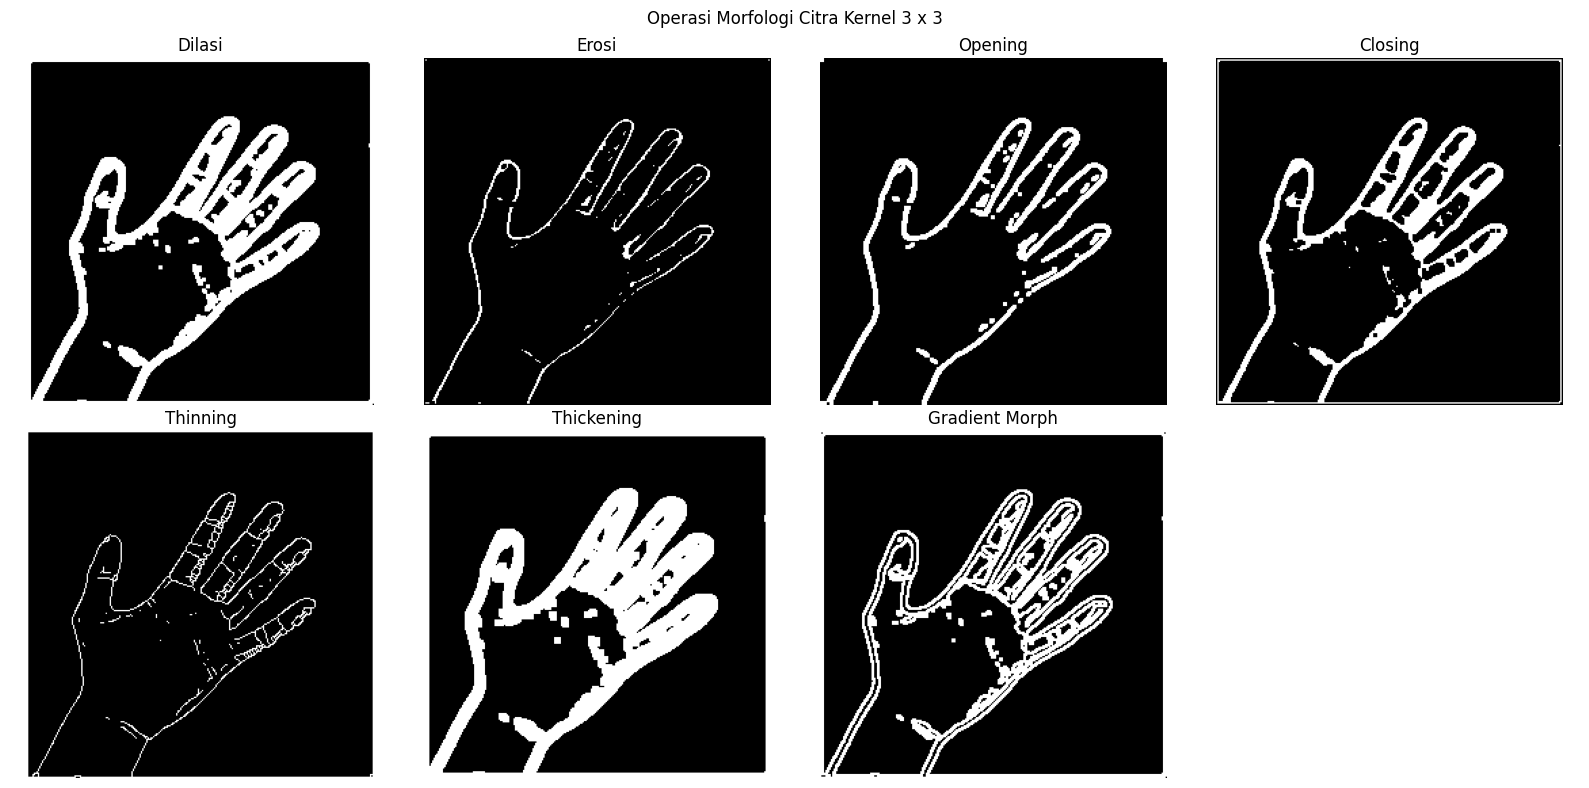

In [19]:
tangan_dilasi = dilasi(thres_tangan, kernel3x3)
tangan_erosi = erosi(thres_tangan, kernel3x3)
tangan_opening = opening(thres_tangan, kernel3x3)
tangan_closing = closing(thres_tangan, kernel3x3)
tangan_thinning = thinning(thres_tangan)
tangan_thickening = thickening(thres_tangan, kernel3x3, 2)
tangan_gradienMorph = gradienMorph(thres_tangan, kernel3x3)

plt.figure(figsize=(16,8))
plt.suptitle("Operasi Morfologi Citra Kernel 3 x 3")
plt.axis("off")
plt.subplot(2,4,1)
plt.title("Dilasi")
plt.axis("off")
plt.imshow(tangan_dilasi, cmap='gray')
plt.subplot(2,4,2)
plt.title("Erosi")
plt.axis("off")
plt.imshow(tangan_erosi, cmap='gray')
plt.subplot(2,4,3)
plt.title("Opening")
plt.axis("off")
plt.imshow(tangan_opening, cmap='gray')
plt.subplot(2,4,4)
plt.title("Closing")
plt.axis("off")
plt.imshow(tangan_closing, cmap='gray')
plt.subplot(2,4,5)
plt.title("Thinning")
plt.axis("off")
plt.imshow(tangan_thinning, cmap='gray')
plt.subplot(2,4,6)
plt.title("Thickening")
plt.axis("off")
plt.imshow(tangan_thickening, cmap='gray')
plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.axis("off")
plt.imshow(tangan_gradienMorph, cmap='gray')
plt.tight_layout()
plt.show()

MORFOLOGI CITRA KERNEL 5 x 5

In [20]:
kernel5x5 = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
], dtype=np.uint8)

Kernel5×5 merupakan structuring element yang lebih besar dibandingkan kernel 3×3. Dengan seluruh 25 elemen bernilai 1 dan jangkauan radius 2 piksel, operasi morfologi menggunakan kernel ini memberikan efek yang jauh lebih agresif , dilasi memperlebar lebih jauh, erosi mengikis lebih dalam, dan kombinasinya berdampak signifikan pada ketebalan objek dan tingkat detail citra.

Perbandingan antara hasil operasi morfologi dengan kernel 5×5 dan 3×3 menunjukkan perbedaan yang jelas pada ketebalan objek, detail citra, tingkat noise, serta bentuk keseluruhan tangan. Pada kernel 5×5, efek morfologi terlihat lebih kuat dan agresif, hasil dilasi membuat objek tangan tampak jauh lebih tebal dan area putih meluas signifikan, sedangkan erosi mengikis bagian putih secara ekstrem hingga hanya menyisakan fragmen kecil.

Operasi opening dan closing dengan kernel besar cenderung menghilangkan detail halus dan menutup lubang kecil, menghasilkan bentuk tangan yang lebih padat tetapi kehilangan kontur tipis. Sebaliknya, kernel 3×3 memberikan efek yang lebih halus dan terkontrol.

Dilasi dan erosi masih mempertahankan bentuk asli tangan dengan ketebalan sedang, sementara opening dan closing menjaga keseimbangan antara penghilangan noise dan pelestarian detail. Pada operasi thinning dan gradient morph, kernel kecil menghasilkan garis tepi yang lebih tajam dan detail jari lebih jelas, sedangkan kernel besar membuat garis tepi lebih tebal dan kurang presisi. Secara keseluruhan, kernel 5×5 cocok untuk pembersihan kasar atau penguatan bentuk besar, sedangkan kernel 3×3 lebih ideal untuk mempertahankan detail dan struktur halus citra biner seperti kontur tangan.

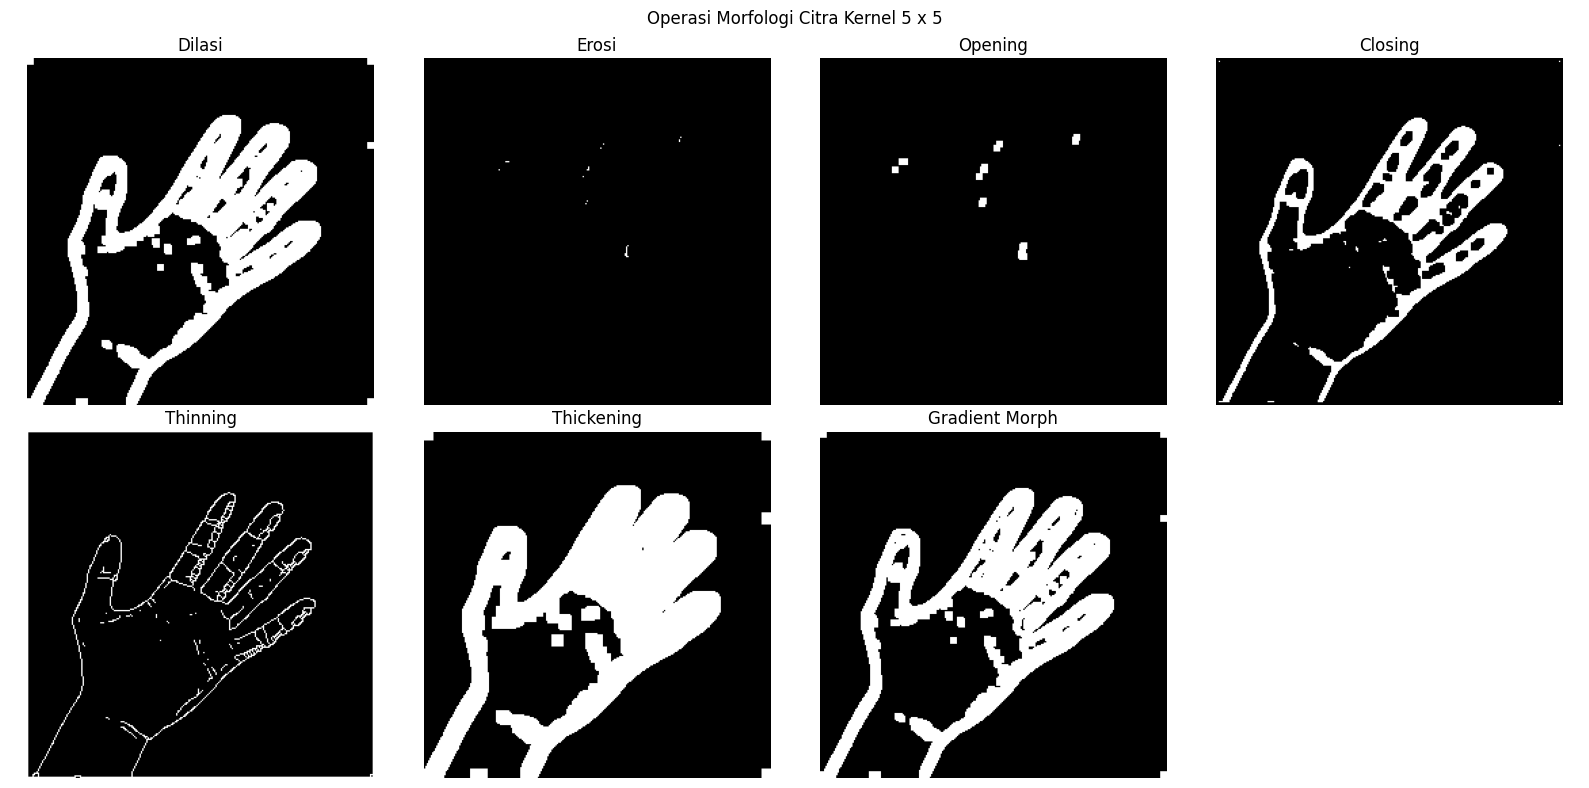

In [21]:
tangan_dilasi = dilasi(thres_tangan, kernel5x5)
tangan_erosi = erosi(thres_tangan, kernel5x5)
tangan_opening = opening(thres_tangan, kernel5x5)
tangan_closing = closing(thres_tangan, kernel5x5)
tangan_thinning = thinning(thres_tangan)
tangan_thickening = thickening(thres_tangan, kernel5x5, 2)
tangan_gradienMorph = gradienMorph(thres_tangan, kernel5x5)

plt.figure(figsize=(16,8))
plt.suptitle("Operasi Morfologi Citra Kernel 5 x 5")
plt.axis("off")
plt.subplot(2,4,1)
plt.title("Dilasi")
plt.axis("off")
plt.imshow(tangan_dilasi, cmap='gray')
plt.subplot(2,4,2)
plt.title("Erosi")
plt.axis("off")
plt.imshow(tangan_erosi, cmap='gray')
plt.subplot(2,4,3)
plt.title("Opening")
plt.axis("off")
plt.imshow(tangan_opening, cmap='gray')
plt.subplot(2,4,4)
plt.title("Closing")
plt.axis("off")
plt.imshow(tangan_closing, cmap='gray')
plt.subplot(2,4,5)
plt.title("Thinning")
plt.axis("off")
plt.imshow(tangan_thinning, cmap='gray')
plt.subplot(2,4,6)
plt.title("Thickening")
plt.axis("off")
plt.imshow(tangan_thickening, cmap='gray')
plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.axis("off")
plt.imshow(tangan_gradienMorph, cmap='gray')
plt.tight_layout()
plt.show()

KOMBINASI 2 PROSES MORFOLOGI


Opening + Closing

Kombinasi Opening dan Closing menghasilkan citra yang lebih bersih dibandingkan operasi tunggal maupun citra threshold asli. Opening yang dilakukan pertama menghilangkan noise kecil dan memutus sambungan tipis antar objek, sehingga detail-detail kecil yang tidak relevan seperti titik-titik putih di area telapak berhasil dieliminasi. Setelah itu, Closing menutup kembali celah-celah kecil yang terbentuk akibat Opening, sehingga kontur tangan terlihat lebih menyambung dan solid. Dibandingkan citra threshold asli, ketebalan objek berkurang sedikit akibat erosi pada tahap Opening, tetapi bentuk keseluruhan tangan tetap terjaga dengan baik. Batas objek menjadi lebih jelas dan tegas karena noise di sekitar tepi berhasil direduksi.


Closing + Opening

Kombinasi Closing dan Opening memberikan hasil yang sedikit berbeda dengan urutan sebelumnya. Closing yang dilakukan pertama memperlebar objek dan menutup celah-celah kecil termasuk celah antar jari, sehingga area putih menjadi lebih luas dan tersambung. Kemudian Opening menipiskan kembali hasil tersebut dan menghilangkan tonjolan-tonjolan kecil di tepi objek. Hasilnya, objek tangan tampak lebih penuh dibandingkan Opening dan Closing karena celah antar jari lebih tertutup sejak awal, tetapi noise halus di area telapak masih sedikit tersisa karena Closing tidak membuang noise melainkan memperkuatnya sebelum Opening bekerja.


Opening + Dilasi

Kombinasi Opening dan Dilasi menghasilkan objek yang lebih tebal dibandingkan kombinasi lainnya. Opening di awal membersihkan noise kecil dan mempertahankan hanya struktur utama tangan, kemudian Dilasi memperlebar seluruh struktur tersebut secara seragam ke semua arah. Akibatnya, kontur tangan menjadi lebih tebal dan area putih bertambah luas dibandingkan citra threshold asli maupun hasil Opening tunggal. tetapi kelemahannya, beberapa detail halus seperti celah antar jari yang sempit bisa tertutup oleh Dilasi, sehingga batas antar jari menjadi kurang jelas. Noise yang sudah dibuang oleh Opening tidak muncul kembali, sehingga hasil akhirnya tetap relatif bersih meski lebih tebal.


Closing + Erosi

Kombinasi Closing dan Erosi secara karakteristik berkebalikan dengan Opening dan Dilasi. Closing pertama menutup celah dan memperlebar objek, kemudian Erosi mengikis tepi objek sehingga ukurannya menyusut kembali. Hasilnya mirip dengan Opening tetapi dengan perilaku berbeda, celah antar jari yang sempat tertutup oleh Closing akan terbuka kembali sebagian oleh Erosi, sehingga batas antar jari terlihat lebih tajam. Dibandingkan citra threshold asli, objek sedikit lebih tipis dan noise kecil berhasil ditekan. Kombinasi ini efektif untuk mempertahankan bentuk global objek sekaligus mempertegas batas tepi, meski pada area yang strukturnya sudah tipis sejak awal bisa berisiko terputus akibat Erosi.

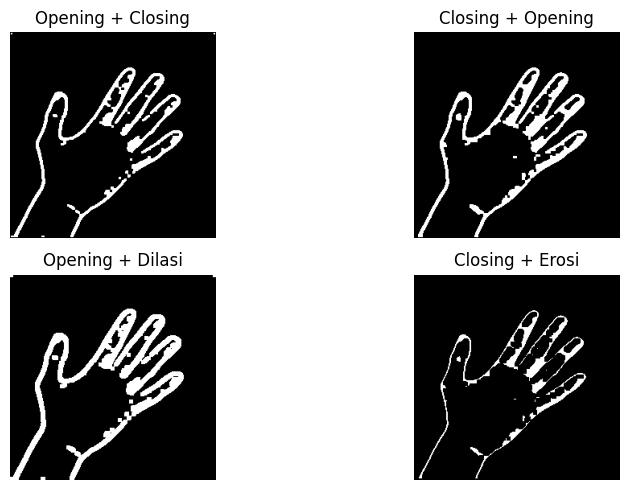

In [22]:
kombo_open = opening(thres_tangan, kernel3x3)
open_clos = closing(kombo_open, kernel3x3)

kombo_clos = closing(thres_tangan, kernel3x3)
clos_open = opening(kombo_clos, kernel3x3)

kombo_open_dilasi = opening(thres_tangan, kernel3x3)
open_dilasi = dilasi(kombo_open_dilasi, kernel3x3)

kombo_clos_erosi = closing(thres_tangan, kernel3x3)
clos_erosi = erosi(kombo_clos_erosi, kernel3x3)

plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.title("Opening + Closing")
plt.axis("off")
plt.imshow(open_clos, cmap='gray')
plt.subplot(2,2,2)
plt.title("Closing + Opening")
plt.axis("off")
plt.imshow(clos_open, cmap='gray')
plt.subplot(2,2,3)
plt.title("Opening + Dilasi")
plt.axis("off")
plt.imshow(open_dilasi, cmap='gray')
plt.subplot(2,2,4)
plt.title("Closing + Erosi")
plt.axis("off")
plt.imshow(clos_erosi, cmap='gray')
plt.tight_layout()
plt.show()

EKSPLORASI MANDIRI

Percobaan eksplorasi menggunakan proses Closing (kernel_diamond), Opening (kernel3×3), Gradient Morph (kernel3×3), dan Thinning. Closing dengan kernel_diamond dipilih karena bentuk belah ketupatnya lebih efektif menutup celah diagonal antar jari dibandingkan kernel kotak, sementara Opening dan Gradient Morph kembali menggunakan kernel3×3 yang seluruh elemennya berisi 1, agar ekspansi dan ekstraksi kontur terjadi secara seragam ke semua arah. Kombinasi ini menghasilkan kontur telapak tangan yang paling jelas dan menyambung, dengan celah antar jari yang lebih tertutup dan garis skeleton yang mewakili bentuk tangan asli.

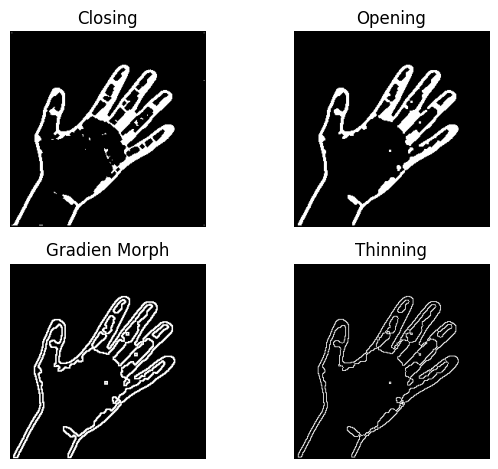

In [25]:
tangan_eksplor = closing(thres_tangan, kernel_diamond)
eksplor2 = opening(tangan_eksplor, kernel3x3)
eksplor3 = gradienMorph(eksplor2, kernel3x3)
eksplor4 = thinning(eksplor3)

plt.subplot(2,2,1)
plt.title("Closing")
plt.axis("off")
plt.imshow(tangan_eksplor, cmap='gray')
plt.subplot(2,2,2)
plt.title("Opening")
plt.axis("off")
plt.imshow(eksplor2, cmap='gray')
plt.subplot(2,2,3)
plt.title("Gradien Morph")
plt.axis("off")
plt.imshow(eksplor3, cmap='gray')
plt.subplot(2,2,4)
plt.title("Thinning")
plt.axis("off")
plt.imshow(eksplor4, cmap='gray')
plt.tight_layout()
plt.show()

ANALISIS DAN KESIMPULAN

Persiapan Citra

Tahap preprocessing merupakan fondasi yang menentukan kualitas seluruh proses morfologi. Proses diawali dengan konversi citra ke grayscale, kemudian dilakukan filter median 5×5 pada citra asli beresolusi tinggi untuk meredam noise sebelum downsampling. Resize menggunakan nearest-neighbor ke 256×256 piksel menghasilkan artefak kotak akibat sifat interpolasi yang tidak menghaluskan transisi, sehingga diperlukan filter median 3×3 tambahan setelah resize untuk meminimalisir artefak tersebut. Setelah itu, smoothing memperhalus citra dan sharpening mempertajam tepi sebelum deteksi tepi dilakukan. Kombinasi operator Sobel dan Prewitt dipilih karena menghasilkan tepi yang lebih kuat dan lengkap dibandingkan operator tunggal, Sobel sensitif terhadap perubahan gradien besar sedangkan Prewitt menangkap perubahan yang lebih merata. Threshold dengan nilai 30 kemudian menghasilkan citra biner sebagai input utama seluruh operasi morfologi.

Morfologi Citra Kernel 3×3

Operasi morfologi dengan kernel 3×3 all-ones memberikan efek yang terkontrol dan proporsional terhadap struktur citra telapak tangan. Dilasi memperlebar kontur secara seragam tetapi turut memperbesar noise, sedangkan erosi mengikis tepi dan menghilangkan noise kecil tetapi berisiko memutus struktur tipis. Opening terbukti efektif membersihkan noise sambil mempertahankan bentuk global tangan, sementara closing berhasil menutup celah internal meski kurang efektif dalam menekan noise. Thinning menghasilkan skeleton tangan yang tipis dan terjaga konektivitasnya menggunakan algoritma Zhang-Suen, sementara thickening dengan 2 iterasi memberikan penebalan kumulatif yang lebih masif dari dilasi tunggal. Gradient morphology paling efektif mengekstrak kontur tepi sebagai selisih dilasi dan erosi, menghasilkan garis batas objek yang presisi. Secara keseluruhan, kernel 3×3 ideal untuk operasi morfologi pada citra kontur tipis karena efeknya tidak terlalu destruktif.

Morfologi Citra Kernel 5×5

Perbandingan kernel 5×5 terhadap 3×3 menunjukkan bahwa ukuran kernel berdampak signifikan pada agresivitas operasi morfologi. Dilasi 5×5 menghasilkan pelebaran yang hampir dua kali lipat, sedangkan erosi 5×5 terlalu destruktif , hampir menghancurkan seluruh struktur citra kontur tipis karena syarat erosi radius 2 piksel jarang terpenuhi. Akibatnya, opening 5×5 juga kehilangan hampir semua informasi bentuk karena bergantung pada erosi di tahap pertama. Closing 5×5 masih mempertahankan bentuk global tangan tetapi menimbulkan lubang-lubang internal akibat erosi yang terlalu agresif di tahap kedua. Thinning tidak terpengaruh ukuran kernel karena bekerja langsung pada struktur piksel secara topologis. Gradient morph 5×5 menghasilkan kontur yang lebih tebal dan kurang detail dibandingkan 3×3. Kesimpulannya, kernel 5×5 lebih cocok untuk citra dengan objek solid dan tebal, bukan untuk citra kontur tipis seperti hasil deteksi tepi.

Kombinasi 2 Proses Morfologi

Kombinasi dua operasi morfologi secara berurutan terbukti menghasilkan efek yang tidak bisa dicapai operasi tunggal. Opening dan Closing memberikan hasil paling seimbang , noise tereliminasi oleh opening, dan celah yang terbuka akibat opening ditutup kembali oleh closing, menghasilkan kontur yang bersih sekaligus menyambung. Closing dan Opening mengutamakan keutuhan bentuk objek terlebih dahulu sebelum membersihkan tonjolan, cocok jika integritas bentuk lebih diprioritaskan daripada kebersihan noise. Opening dan Dilasi menghasilkan objek paling tebal tetapi paling rapat, efektif jika diinginkan kontur yang solid. Closing dan Erosi mempertajam batas tepi setelah mengisi celah, menghasilkan definisi batas yang lebih tajam tetapi berisiko memutus struktur tipis. Urutan operasi sangat menentukan hasil akhir, dua operasi yang sama dengan urutan berbeda menghasilkan karakteristik citra yang berbeda secara signifikan.

Eksplorasi Mandiri

Eksplorasi mandiri bertujuan menghasilkan citra outline atau kontur telapak tangan yang sejelasnya melalui kombinasi operasi morfologi yang dipilih secara bebas. Dari percobaan yang dilakukan, hasil yang terbaik adalah Closing (kernel_diamond), Opening (kernel3×3), Gradient Morph (kernel3×3), Thinning. Closing dengan kernel_diamond dipilih karena bentuk belah ketupatnya lebih efektif menutup celah diagonal antar jari dibandingkan kernel kotak, sehingga permasalahan celah antara jari tengah dan jari manis berhasil diminimalisir. Opening kemudian membersihkan sisa noise tanpa terlalu merusak struktur. Gradient morph mengekstrak hanya zona tepi objek, dan thinning sebagai tahap akhir menipiskan kontur menjadi garis skeleton yang representatif. Perbandingan tiga percobaan menunjukkan bahwa pemilihan bentuk kernel, bukan hanya ukurannya, berpengaruh signifikan terhadap hasil morfologi, kernel_diamond lebih tepat untuk struktur diagonal sedangkan kernel_cross lebih tepat untuk struktur horizontal/vertikal.

Kesimpulan

Praktikum morfologi citra ini menunjukkan bahwa operasi morfologi merupakan alat yang powerful tetapi sangat bergantung pada dua faktor utama: ukuran kernel dan urutan operasi. Kernel yang terlalu besar dapat merusak detail halus, sedangkan kernel terlalu kecil tidak cukup kuat menutup celah atau menekan noise. Pemilihan bentuk kernel (kotak, diamond, cross) juga berpengaruh karena menentukan arah dan selektivitas ekspansi atau erosi. Tahap preprocessing yang baik, khususnya filtering ganda sebelum dan sesudah resize, serta kombinasi dua operator deteksi tepi, terbukti krusial dalam menghasilkan citra biner berkualitas sebagai input morfologi. morfologi yang optimal untuk menghasilkan kontur telapak tangan yang jelas adalah dengan menggabungkan operasi yang saling melengkapi: closing untuk mengisi celah, opening untuk membersihkan noise, gradient morph untuk mengekstrak tepi, dan thinning untuk menghasilkan skeleton akhir yang tipis dan bersambung.